In [2]:
from matplotlib.patches import FancyArrowPatch
from scipy import ndimage as ndi
from scipy.ndimage import label
from scipy.ndimage import map_coordinates
from scipy.ndimage import maximum_filter, label
from scipy.optimize import curve_fit
from scipy.stats import gaussian_kde
from scipy.stats import lognorm
from scipy.stats import skewnorm
from skimage import measure
from skimage import morphology
from skimage import morphology, measure
from skimage.segmentation import find_boundaries
import h5py
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns
from scipy.ndimage import label, maximum_filter
from concurrent.futures import ProcessPoolExecutor

In [3]:
#Defining all the required functions
#Fourier Transform Functions
def partial_x_fft(f, dx):
    nx, ny = f.shape
    kx = 2 * np.pi * np.fft.fftfreq(nx, d=dx)
    f_fft = np.fft.fft(f, axis=0)
    df_fft = 1j * kx[:, None] * f_fft
    return np.real(np.fft.ifft(df_fft, axis=0))

def partial_y_fft(f, dy):
    nx, ny = f.shape
    ky = 2 * np.pi * np.fft.fftfreq(ny, d=dy)
    f_fft = np.fft.fft(f, axis=1)
    df_fft = 1j * ky[None, :] * f_fft
    return np.real(np.fft.ifft(df_fft, axis=1))

#Denoising the data
def gaussian_fft_filter_2d(J_squared, k0):
    """
    Apply a Gaussian low-pass filter in Fourier space to a 2D field.

    Parameters
    ----------
    J_squared : 2D numpy array
        Input real-space data
    k0 : float
        Filter width in k-space (grid units). Smaller = stronger smoothing.

    Returns
    -------
    J_filtered : 2D numpy array
        Smoothed real-space data
    """

    # FFT
    F = np.fft.fft2(J_squared)
    F_shifted = np.fft.fftshift(F)

    # k-grid
    nx, ny = J_squared.shape
    kx = np.fft.fftshift(np.fft.fftfreq(nx)) * nx
    ky = np.fft.fftshift(np.fft.fftfreq(ny)) * ny
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    K2 = KX**2 + KY**2

    # Gaussian filter in k-space
    gaussian = np.exp(-K2 / (2 * k0**2))

    # Apply filter
    F_filt = F_shifted * gaussian

    # Inverse FFT
    F_filt = np.fft.ifftshift(F_filt)
    J_filtered = np.fft.ifft2(F_filt)

    # Return real part
    return np.real(J_filtered)

def ComputeThicknessM1(
    t,
    base_path,
    dx,
    dy,
    k0_frac=0.2,
    quantile_threshold=0.8,
    disk_size=5,
    min_area=300,
):
    """
    Compute current-sheet thicknesses using Method-1
    (largest inscribed circle).

    Parameters
    ----------
    t : int
        Simulation time.
    base_path : str
        Directory containing Bx, By, Bz files.
    dx, dy : float
        Grid spacing.
    k0_frac : float
        Fraction of box size for Gaussian FFT filter.
    quantile_threshold : float
        Threshold percentile for J^2 selection.
    disk_size : int
        Morphological smoothing scale.
    min_area : int
        Minimum connected-region area.

    Returns
    -------
    dict containing:
        thicknesses : list
        mean_thickness
        median_thickness
        min_thickness
        max_thickness
        num_regions
        J_squared
        cleaned_mask
        maxima_coords
    """

    # --------------------------------------------------
    # Load fields
    # --------------------------------------------------
    File_Bx = f"{base_path}/Bx_ApJ_t{t}.h5"
    File_By = f"{base_path}/By_ApJ_t{t}.h5"
    File_Bz = f"{base_path}/Bz_ApJ_t{t}.h5"

    with h5py.File(File_Bx, "r") as fBx, \
         h5py.File(File_By, "r") as fBy, \
         h5py.File(File_Bz, "r") as fBz:

        data_Bx = fBx["DS1"][:].T
        data_By = fBy["DS1"][:].T
        data_Bz = fBz["DS1"][:].T

    # --------------------------------------------------
    # Filtering
    # --------------------------------------------------
    k0 = k0_frac * len(data_Bx)

    Bx_f = gaussian_fft_filter_2d(data_Bx, k0=k0)
    By_f = gaussian_fft_filter_2d(data_By, k0=k0)
    Bz_f = gaussian_fft_filter_2d(data_Bz, k0=k0)

    # --------------------------------------------------
    # Compute Current Density
    # --------------------------------------------------
    Jx = partial_y_fft(Bz_f, dx)
    Jy = -partial_x_fft(Bz_f, dy)
    Jz = partial_x_fft(By_f, dy) - partial_y_fft(Bx_f, dx)

    J_squared = Jx**2 + Jy**2 + Jz**2
    J_squared = gaussian_fft_filter_2d(J_squared, k0=k0)

    # --------------------------------------------------
    # Thresholding
    # --------------------------------------------------
    threshold = np.quantile(J_squared, quantile_threshold)
    binary_mask = np.abs(J_squared) > threshold

    # --------------------------------------------------
    # Morphological Cleaning
    # --------------------------------------------------
    struct = morphology.disk(disk_size)

    smoothed_mask = morphology.binary_opening(binary_mask, struct)
    smoothed_mask = morphology.binary_closing(smoothed_mask, struct)

    cleaned_mask = morphology.remove_small_objects(
        smoothed_mask.astype(bool),
        min_size=min_area
    )

    cleaned_mask = cleaned_mask.astype(int)

    # --------------------------------------------------
    # Connected regions + maxima
    # --------------------------------------------------
    labeled_mask, num_features = label(cleaned_mask)

    max_coords = []
    max_values = []

    for i in range(1, num_features + 1):

        region_mask = labeled_mask == i
        region_vals = J_squared[region_mask]

        if region_vals.size == 0:
            continue

        max_pos = np.argmax(np.abs(region_vals))
        extreme_value = region_vals[max_pos]
        max_values.append(extreme_value)

        xs, ys = np.where(region_mask)
        max_coords.append((xs[max_pos], ys[max_pos]))

    # --------------------------------------------------
    # Thickness Method 1
    # --------------------------------------------------
    labeled_mask = measure.label(cleaned_mask, connectivity=2)
    num_regions = labeled_mask.max()

    thicknesses = []

    for label_id in range(1, num_regions + 1):

        region = labeled_mask == label_id
        dist = ndi.distance_transform_edt(region)

        thickness = 2 * dist.max()
        thicknesses.append(thickness)

    thicknesses = np.array(thicknesses)

    # --------------------------------------------------
    # Statistics
    # --------------------------------------------------
    if len(thicknesses) > 0:
        stats = dict(
            mean_thickness=np.mean(thicknesses),
            median_thickness=np.median(thicknesses),
            min_thickness=np.min(thicknesses),
            max_thickness=np.max(thicknesses),
        )
    else:
        stats = dict(
            mean_thickness=np.nan,
            median_thickness=np.nan,
            min_thickness=np.nan,
            max_thickness=np.nan,
        )

    # --------------------------------------------------
    return {
        "thicknesses": thicknesses,
        "num_regions": num_regions,
        "J_squared": J_squared,
        "cleaned_mask": cleaned_mask,
        "maxima_coords": max_coords,
        **stats,
    }


def ComputeThicknessM2(
    t,
    base_path,
    dx,
    dy,
    k0_frac=0.2,
    quantile_threshold=0.8,
    disk_size=5,
    min_area=300,
    step_size=1.0,
    max_steps=1000,
):
    """
    Method 2:
    Thickness measured along direction of steepest descent
    of J^2 from each sheet maximum.

    Returns
    -------
    dict containing:
        thicknesses
        forward_distances
        backward_distances
        descent_dirs
        maxima_coords
        cleaned_mask
        J_squared
        num_regions
    """

    # --------------------------------------------------
    # Load fields
    # --------------------------------------------------
    File_Bx = f"{base_path}/Bx_ApJ_t{t}.h5"
    File_By = f"{base_path}/By_ApJ_t{t}.h5"
    File_Bz = f"{base_path}/Bz_ApJ_t{t}.h5"

    with h5py.File(File_Bx, "r") as fBx, \
         h5py.File(File_By, "r") as fBy, \
         h5py.File(File_Bz, "r") as fBz:

        data_Bx = fBx["DS1"][:].T
        data_By = fBy["DS1"][:].T
        data_Bz = fBz["DS1"][:].T

    # --------------------------------------------------
    # Filtering
    # --------------------------------------------------
    k0 = k0_frac * len(data_Bx)

    Bx_f = gaussian_fft_filter_2d(data_Bx, k0=k0)
    By_f = gaussian_fft_filter_2d(data_By, k0=k0)
    Bz_f = gaussian_fft_filter_2d(data_Bz, k0=k0)

    # --------------------------------------------------
    # Current density
    # --------------------------------------------------
    Jx = partial_y_fft(Bz_f, dx)
    Jy = -partial_x_fft(Bz_f, dy)
    Jz = partial_x_fft(By_f, dy) - partial_y_fft(Bx_f, dx)

    J_squared = Jx**2 + Jy**2 + Jz**2
    J_squared = gaussian_fft_filter_2d(J_squared, k0=k0)

    # --------------------------------------------------
    # Threshold + morphology
    # --------------------------------------------------
    threshold = np.quantile(J_squared, quantile_threshold)
    binary_mask = np.abs(J_squared) > threshold

    struct = morphology.disk(disk_size)

    smoothed_mask = morphology.binary_opening(binary_mask, struct)
    smoothed_mask = morphology.binary_closing(smoothed_mask, struct)

    cleaned_mask = morphology.remove_small_objects(
        smoothed_mask.astype(bool),
        min_size=min_area
    )

    cleaned_mask = cleaned_mask.astype(int)

    # --------------------------------------------------
    # Connected regions + maxima
    # --------------------------------------------------
    labeled_mask, num_regions = label(cleaned_mask)

    max_coords = []

    for i in range(1, num_regions + 1):

        region_mask = labeled_mask == i
        region_vals = J_squared[region_mask]

        if region_vals.size == 0:
            continue

        max_pos = np.argmax(np.abs(region_vals))
        xs, ys = np.where(region_mask)

        max_coords.append((xs[max_pos], ys[max_pos]))

    # --------------------------------------------------
    # Gradient of J^2
    # --------------------------------------------------
    dJdx, dJdy = np.gradient(J_squared)

    descent_dirs = []

    for (x, y) in max_coords:

        gx = dJdx[x, y]
        gy = dJdy[x, y]

        grad = np.array([gx, gy])

        if np.allclose(grad, 0):
            descent_dirs.append(np.array([0.0, 0.0]))
        else:
            descent_dirs.append(-grad / np.linalg.norm(grad))

    # --------------------------------------------------
    # Thickness along steepest descent
    # --------------------------------------------------
    forward_distances = []
    backward_distances = []
    thicknesses = []

    nx, ny = cleaned_mask.shape

    for (x, y), (dx_dir, dy_dir) in zip(max_coords, descent_dirs):

        x0, y0 = float(x), float(y)

        # ---------- forward ----------
        xf, yf = x0, y0
        steps = 0

        while steps < max_steps:
            xf_new = xf + dx_dir * step_size
            yf_new = yf + dy_dir * step_size

            xi, yi = int(round(xf_new)), int(round(yf_new))

            if xi < 0 or yi < 0 or xi >= nx or yi >= ny:
                break
            if not cleaned_mask[xi, yi]:
                break

            xf, yf = xf_new, yf_new
            steps += 1

        dist_forward = np.hypot(xf - x0, yf - y0)

        # ---------- backward ----------
        xb, yb = x0, y0
        steps = 0

        while steps < max_steps:
            xb_new = xb - dx_dir * step_size
            yb_new = yb - dy_dir * step_size

            xi, yi = int(round(xb_new)), int(round(yb_new))

            if xi < 0 or yi < 0 or xi >= nx or yi >= ny:
                break
            if not cleaned_mask[xi, yi]:
                break

            xb, yb = xb_new, yb_new
            steps += 1

        dist_backward = np.hypot(xb - x0, yb - y0)

        forward_distances.append(dist_forward)
        backward_distances.append(dist_backward)

        thicknesses.append(dist_forward + dist_backward)

    thicknesses = np.array(thicknesses)

    # --------------------------------------------------
    # Statistics
    # --------------------------------------------------
    if len(thicknesses) > 0:
        stats = dict(
            mean_thickness=np.mean(thicknesses),
            median_thickness=np.median(thicknesses),
            min_thickness=np.min(thicknesses),
            max_thickness=np.max(thicknesses),
        )
    else:
        stats = dict(
            mean_thickness=np.nan,
            median_thickness=np.nan,
            min_thickness=np.nan,
            max_thickness=np.nan,
        )

    # --------------------------------------------------
    return {
        "thicknesses": thicknesses,
        "forward_distances": forward_distances,
        "backward_distances": backward_distances,
        "descent_dirs": descent_dirs,
        "maxima_coords": max_coords,
        "cleaned_mask": cleaned_mask,
        "J_squared": J_squared,
        "num_regions": num_regions,
        **stats,
    }


def ComputeThicknessM3(
    t,
    base_path,
    dx,
    dy,
    k0_frac=0.2,
    quantile_threshold=0.8,
    disk_size=5,
    min_area=300,
    max_len=60,
    step_px=1,
):
    """
    Method 3:
    Thickness from Gaussian FWHM of J^2 profile
    sampled along steepest-descent direction.

    Returns
    -------
    dict containing:
        thicknesses
        fwhms
        popts
        pcovs
        maxima_coords
        descent_dirs
        J_squared
        cleaned_mask
        num_regions
    """

    # --------------------------------------------------
    # Gaussian model
    # --------------------------------------------------
    def gaussian(t, A, mu, sigma, B):
        return A * np.exp(-(t - mu) ** 2 / (2 * sigma**2)) + B

    # --------------------------------------------------
    # Load fields
    # --------------------------------------------------
    File_Bx = f"{base_path}/Bx_ApJ_t{t}.h5"
    File_By = f"{base_path}/By_ApJ_t{t}.h5"
    File_Bz = f"{base_path}/Bz_ApJ_t{t}.h5"

    with h5py.File(File_Bx, "r") as fBx, \
         h5py.File(File_By, "r") as fBy, \
         h5py.File(File_Bz, "r") as fBz:

        data_Bx = fBx["DS1"][:].T
        data_By = fBy["DS1"][:].T
        data_Bz = fBz["DS1"][:].T

    # --------------------------------------------------
    # Filtering
    # --------------------------------------------------
    k0 = k0_frac * len(data_Bx)

    Bx_f = gaussian_fft_filter_2d(data_Bx, k0=k0)
    By_f = gaussian_fft_filter_2d(data_By, k0=k0)
    Bz_f = gaussian_fft_filter_2d(data_Bz, k0=k0)

    # --------------------------------------------------
    # Current density
    # --------------------------------------------------
    Jx = partial_y_fft(Bz_f, dx)
    Jy = -partial_x_fft(Bz_f, dy)
    Jz = partial_x_fft(By_f, dy) - partial_y_fft(Bx_f, dx)

    J_squared = Jx**2 + Jy**2 + Jz**2
    J_squared = gaussian_fft_filter_2d(J_squared, k0=k0)

    # --------------------------------------------------
    # Threshold + morphology
    # --------------------------------------------------
    threshold = np.quantile(J_squared, quantile_threshold)
    binary_mask = np.abs(J_squared) > threshold

    struct = morphology.disk(disk_size)

    smoothed_mask = morphology.binary_opening(binary_mask, struct)
    smoothed_mask = morphology.binary_closing(smoothed_mask, struct)

    cleaned_mask = morphology.remove_small_objects(
        smoothed_mask.astype(bool),
        min_size=min_area
    ).astype(int)

    # --------------------------------------------------
    # Connected regions + maxima
    # --------------------------------------------------
    labeled_mask, num_regions = label(cleaned_mask)

    max_coords = []

    for i in range(1, num_regions + 1):
        region_mask = labeled_mask == i
        region_vals = J_squared[region_mask]

        if region_vals.size == 0:
            continue

        max_pos = np.argmax(np.abs(region_vals))
        xs, ys = np.where(region_mask)
        max_coords.append((xs[max_pos], ys[max_pos]))

    # --------------------------------------------------
    # Gradient → descent directions
    # --------------------------------------------------
    dJdx, dJdy = np.gradient(J_squared)

    descent_dirs = []

    for (x, y) in max_coords:

        grad = np.array([dJdx[x, y], dJdy[x, y]])

        if np.allclose(grad, 0):
            descent_dirs.append(np.array([0.0, 0.0]))
        else:
            descent_dirs.append(-grad / np.linalg.norm(grad))

    # --------------------------------------------------
    # Gaussian profile fitting
    # --------------------------------------------------
    fwhms = []
    popts_list = []
    pcovs_list = []

    nx, ny = J_squared.shape

    for (x, y), (dx_dir, dy_dir) in zip(max_coords, descent_dirs):

        # Skip undefined normal
        if dx_dir == 0 and dy_dir == 0:
            fwhms.append(np.nan)
            popts_list.append([np.nan]*4)
            pcovs_list.append([np.nan]*4)
            continue

        xs = []
        vals = []

        # Sample profile
        for k in range(-max_len, max_len + 1):

            xc = x + k * dx_dir * step_px
            yc = y + k * dy_dir * step_px

            xi = int(round(xc))
            yi = int(round(yc))

            if 0 <= xi < nx and 0 <= yi < ny:
                xs.append(k)
                vals.append(J_squared[xi, yi])

        xs = np.array(xs)
        vals = np.array(vals)

        if len(vals) < 3:
            fwhms.append(np.nan)
            popts_list.append([np.nan]*4)
            pcovs_list.append([np.nan]*4)
            continue

        # Initial guess
        A0 = vals.max() - vals.min()
        mu0 = xs[np.argmax(vals)]
        sigma0 = max_len / 4
        B0 = vals.min()

        try:
            popt, pcov = curve_fit(
                gaussian,
                xs,
                vals,
                p0=[A0, mu0, sigma0, B0]
            )

            _, _, sigma, _ = popt

            fwhm = 2 * np.sqrt(2 * np.log(2)) * sigma

            fwhms.append(fwhm)
            popts_list.append(popt)
            pcovs_list.append(pcov)

        except RuntimeError:
            fwhms.append(np.nan)
            popts_list.append([np.nan]*4)
            pcovs_list.append([np.nan]*4)

    # --------------------------------------------------
    # Cleaning thickness values
    # --------------------------------------------------
    fwhms_array = np.array(fwhms)

    thicknesses = fwhms_array[
        (~np.isnan(fwhms_array))
        & (fwhms_array > 0)
        & (fwhms_array <= 100)
    ]

    # --------------------------------------------------
    # Statistics
    # --------------------------------------------------
    if len(thicknesses) > 0:
        stats = dict(
            mean_thickness=np.mean(thicknesses),
            median_thickness=np.median(thicknesses),
            min_thickness=np.min(thicknesses),
            max_thickness=np.max(thicknesses),
        )
    else:
        stats = dict(
            mean_thickness=np.nan,
            median_thickness=np.nan,
            min_thickness=np.nan,
            max_thickness=np.nan,
        )

    # --------------------------------------------------
    return {
        "thicknesses": thicknesses,
        "fwhms": fwhms_array,
        "popts": popts_list,
        "pcovs": pcovs_list,
        "maxima_coords": max_coords,
        "descent_dirs": descent_dirs,
        "J_squared": J_squared,
        "cleaned_mask": cleaned_mask,
        "num_regions": num_regions,
        **stats,
    }


def ComputeThicknessM4(
    t,
    base_path,
    dx,
    dy,
    k0_frac=0.2,
    disk_size=2,
    n=50,
    peak_rms_factor=3.0,
    region_fraction=0.005,
    step_size=1.0,
    max_steps=1000,
):
    """
    Method 4 (Zhdankin algorithm)

    Steps:
        1. Detect local maxima
        2. Grow regions connected to maxima
        3. Compute thickness along steepest descent

    Returns
    -------
    dict containing:
        thicknesses
        maxima_coords
        descent_dirs
        smoothed_mask
        J_squared
        num_regions
    """

    # --------------------------------------------------
    # Helper functions
    # --------------------------------------------------
    def local_maxima_mask(field, threshold, n):

        mask = field > threshold
        local_max = maximum_filter(field, size=(2*n+1), mode='wrap')

        maxima_mask = (field == local_max) & mask
        return maxima_mask.astype(int)

    def grow_regions(J2, maxima_mask, J_thresh_region):

        J_abs = np.abs(J2)
        above_thresh = (J_abs > J_thresh_region).astype(int)

        labeled_regions, _ = label(
            above_thresh,
            structure=np.ones((3, 3))
        )

        keep_labels = np.unique(
            labeled_regions[maxima_mask.astype(bool)]
        )
        keep_labels = keep_labels[keep_labels > 0]

        region_mask = np.isin(
            labeled_regions,
            keep_labels
        ).astype(int)

        return region_mask, labeled_regions

    # --------------------------------------------------
    # Load fields
    # --------------------------------------------------
    File_Bx = f"{base_path}/Bx_ApJ_t{t}.h5"
    File_By = f"{base_path}/By_ApJ_t{t}.h5"
    File_Bz = f"{base_path}/Bz_ApJ_t{t}.h5"

    with h5py.File(File_Bx, "r") as fBx, \
         h5py.File(File_By, "r") as fBy, \
         h5py.File(File_Bz, "r") as fBz:

        data_Bx = fBx["DS1"][:].T
        data_By = fBy["DS1"][:].T
        data_Bz = fBz["DS1"][:].T

    # --------------------------------------------------
    # Filtering
    # --------------------------------------------------
    k0 = k0_frac * len(data_Bx)

    Bx_f = gaussian_fft_filter_2d(data_Bx, k0=k0)
    By_f = gaussian_fft_filter_2d(data_By, k0=k0)
    Bz_f = gaussian_fft_filter_2d(data_Bz, k0=k0)

    # --------------------------------------------------
    # Current density
    # --------------------------------------------------
    Jx = partial_y_fft(Bz_f, dx)
    Jy = -partial_x_fft(Bz_f, dy)
    Jz = partial_x_fft(By_f, dy) - partial_y_fft(Bx_f, dx)

    J_squared = Jx**2 + Jy**2 + Jz**2
    J_squared = gaussian_fft_filter_2d(J_squared, k0=k0)

    # --------------------------------------------------
    # Thresholds
    # --------------------------------------------------
    J_rms = np.sqrt(np.mean(J_squared**2))

    J2_thresh_peak = peak_rms_factor * J_rms
    J2_thresh_region = region_fraction * np.max(J_squared)

    # --------------------------------------------------
    # Step 1 — detect maxima
    # --------------------------------------------------
    maxima_mask = local_maxima_mask(
        J_squared,
        J2_thresh_peak,
        n
    )

    # --------------------------------------------------
    # Step 2 — grow regions
    # --------------------------------------------------
    region_mask, _ = grow_regions(
        J_squared,
        maxima_mask,
        J2_thresh_region
    )

    # --------------------------------------------------
    # Morphological smoothing
    # --------------------------------------------------
    struct = morphology.disk(disk_size)

    smoothed_mask = morphology.binary_opening(region_mask, struct)
    smoothed_mask = morphology.binary_closing(smoothed_mask, struct)
    smoothed_mask = smoothed_mask.astype(int)

    labeled_mask, num_regions = label(smoothed_mask)

    # --------------------------------------------------
    # Maxima coordinates
    # --------------------------------------------------
    y_peak, x_peak = np.where(maxima_mask == 1)
    max_coords = list(zip(y_peak, x_peak))

    # --------------------------------------------------
    # Steepest descent directions
    # --------------------------------------------------
    dJdx, dJdy = np.gradient(J_squared)

    descent_dirs = []

    for (x, y) in max_coords:

        grad = np.array([dJdx[x, y], dJdy[x, y]])

        if np.allclose(grad, 0):
            descent_dirs.append(np.array([0.0, 0.0]))
        else:
            descent_dirs.append(-grad / np.linalg.norm(grad))

    # --------------------------------------------------
    # Thickness measurement
    # --------------------------------------------------
    nx, ny = smoothed_mask.shape
    thicknesses = []

    for (x, y), (dx_dir, dy_dir) in zip(max_coords, descent_dirs):

        x0, y0 = float(x), float(y)

        # forward
        xf, yf = x0, y0
        steps = 0

        while steps < max_steps:
            xf_new = xf + dx_dir * step_size
            yf_new = yf + dy_dir * step_size

            xi, yi = int(round(xf_new)), int(round(yf_new))

            if xi < 0 or yi < 0 or xi >= nx or yi >= ny:
                break
            if not smoothed_mask[xi, yi]:
                break

            xf, yf = xf_new, yf_new
            steps += 1

        dist_forward = np.hypot(xf - x0, yf - y0)

        # backward
        xb, yb = x0, y0
        steps = 0

        while steps < max_steps:
            xb_new = xb - dx_dir * step_size
            yb_new = yb - dy_dir * step_size

            xi, yi = int(round(xb_new)), int(round(yb_new))

            if xi < 0 or yi < 0 or xi >= nx or yi >= ny:
                break
            if not smoothed_mask[xi, yi]:
                break

            xb, yb = xb_new, yb_new
            steps += 1

        dist_backward = np.hypot(xb - x0, yb - y0)

        thicknesses.append(dist_forward + dist_backward)

    thicknesses = np.array(thicknesses)

    # Cleaning
    thicknesses = thicknesses[
        (thicknesses > 0) & (thicknesses <= 100)
    ]

    # --------------------------------------------------
    # Statistics
    # --------------------------------------------------
    if len(thicknesses) > 0:
        stats = dict(
            mean_thickness=np.mean(thicknesses),
            median_thickness=np.median(thicknesses),
            min_thickness=np.min(thicknesses),
            max_thickness=np.max(thicknesses),
        )
    else:
        stats = dict(
            mean_thickness=np.nan,
            median_thickness=np.nan,
            min_thickness=np.nan,
            max_thickness=np.nan,
        )

    # --------------------------------------------------
    return {
        "thicknesses": thicknesses,
        "maxima_coords": max_coords,
        "descent_dirs": descent_dirs,
        "smoothed_mask": smoothed_mask,
        "J_squared": J_squared,
        "num_regions": num_regions,
        **stats,
    }


In [4]:
#Defining constants
dx = 0.0625
dy = 0.0625

In [5]:
def run_m1(t):
    return ComputeThicknessM1(
        t,
        base_path="/home/UNN/w24021992/NAS/simulations_beta_scan/beta_p_0.0625/beta_e_1",
        dx=dx,
        dy=dy
    )["thicknesses"]


times = list(range(40, 90, 5))

n_workers = os.cpu_count()   # or set manually

with ProcessPoolExecutor(max_workers=n_workers) as executor:
    thickness_m1_00625 = list(executor.map(run_m1, times))

In [6]:
def run_m1(t):
    return ComputeThicknessM1(
        t,
        base_path="/home/UNN/w24021992/NAS/simulations_beta_scan/beta_p_1/beta_e_1",
        dx=dx,
        dy=dy
    )["thicknesses"]


times = list(range(40, 90, 5))

n_workers = os.cpu_count()   # or set manually

with ProcessPoolExecutor(max_workers=n_workers) as executor:
    thickness_m1_1 = list(executor.map(run_m1, times))

In [7]:
def run_m1(t):
    return ComputeThicknessM1(
        t,
        base_path="/home/UNN/w24021992/NAS/simulations_beta_scan/beta_p_16/beta_e_1",
        dx=dx,
        dy=dy
    )["thicknesses"]


times = list(range(40, 90, 5))

n_workers = os.cpu_count()   # or set manually

with ProcessPoolExecutor(max_workers=n_workers) as executor:
    thickness_m1_16 = list(executor.map(run_m1, times))

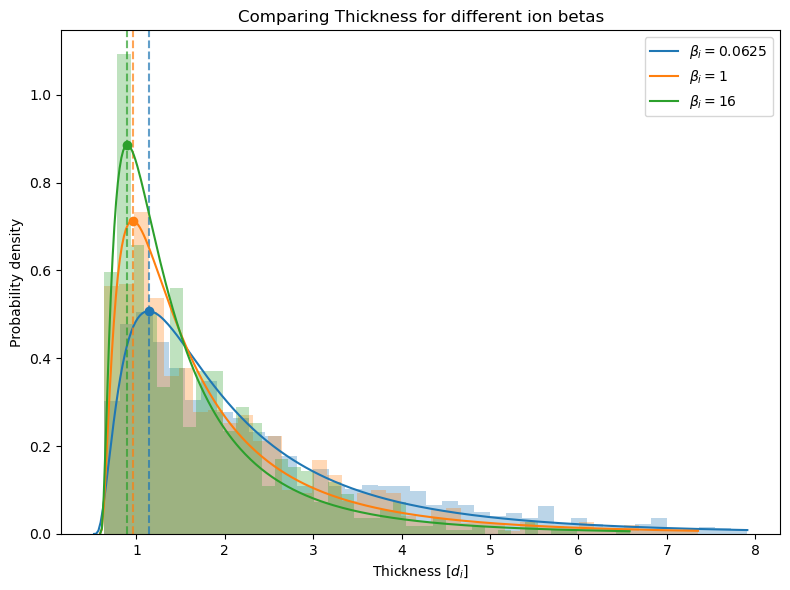

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

datasets = [thickness_m1_00625, thickness_m1_1, thickness_m1_16]
labels   = ['0.0625', '1', '16']  # convert to floats
colors   = ["C0", "C1", "C2"]

plt.figure(figsize=(8,6))

for data, beta_i, color in zip(datasets, labels, colors):
    # Concatenate all arrays and keep values below 128
    x = np.concatenate(data)
    x = x[x < 128]
    
    # Convert pixels → d_i units and remove non-positive values
    x_di = x / 16.0
    x_di = x_di[x_di > 0]
    
    if len(x_di) == 0:
        print(f"Warning: beta_i={beta_i} has no positive data. Skipping.")
        continue
    
    # Fit log-normal (loc not fixed)
    shape, loc, scale = lognorm.fit(x_di)
    
    # xs should cover the range above loc
    xs = np.linspace(loc, x_di.max(), 300)
    
    # Compute mode for loc != 0
    x_mode = loc + scale * np.exp(-shape**2)
    y_mode = lognorm.pdf(x_mode, shape, loc, scale)
    
    # Plot histogram and PDF
    plt.hist(x_di, bins=40, density=True, alpha=0.3, color=color)
    plt.plot(xs, lognorm.pdf(xs, shape, loc, scale),
         color=color,
         label=fr"$\beta_i = {beta_i}$")
    
    # Mark mode
    plt.axvline(x_mode, linestyle="--", color=color, alpha=0.7)
    plt.scatter([x_mode], [y_mode], color=color, zorder=3)

plt.xlabel(r"Thickness [$d_i$]")
plt.ylabel("Probability density")
plt.title("Comparing Thickness for different ion betas")
plt.legend()
plt.tight_layout()
plt.savefig("J2_NR_ComparisonBeta_PDF.png", dpi=300)
plt.show()

In [ ]:
thickness_m1_16